In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bharshana/news-category/news_category.csv


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [36]:
data = pd.read_csv("/kaggle/input/datasets/bharshana/news-category/news_category.csv")
data.head()

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [37]:
data_cleaning=data["headline"].dropna()

In [38]:
def lower_order(text):
    small_order_text=text.lower()
    return small_order_text

In [39]:
def remove_urls(text):
    url_pattern=re.compile(r'http\S+|www\S+|@\w+|#\w+|\d+')
    return url_pattern.sub(r"", text)

In [40]:
!pip install --quiet contractions
import contractions
def handle_contractions(text):
    contraction_fixed_text = contractions.fix(text)
    return contraction_fixed_text

In [41]:
def remove_emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r' ', string)

In [42]:
from nltk.tokenize import RegexpTokenizer
def remove_punct(text):
    tokenizer = RegexpTokenizer(r"\w+")
    tokens = tokenizer.tokenize(text)
    return ' '.join(tokens)

In [43]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text_tokens):
    result_tokens = []
    for token in text_tokens:
        if token not in stop_words:
            result_tokens.append(token)
    return result_tokens

In [44]:
def lemmatization(token_text):
    lemma_tokens = []
    wordnet = WordNetLemmatizer()
    lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]
    return lemmatized_tokens

In [45]:
def text_cleaning_pipeline(dataset):
    # Convert the input to lower order.
    data = lower_order(dataset)
    
    # Remove URLs
    data = remove_urls(data)

    #Handle Contractions
    data = handle_contractions(data)
    
    # Remove emojis
    data = remove_emoji(data)
  
    # Remove punctuations.
    data = remove_punct(data)
  
    # Create tokens.
    tokens = data.split()
  
    # Remove stopwords:
    tokens = remove_stopwords(tokens)

    #Lemmatize words:
    tokens = lemmatization(tokens)

    return " ".join(tokens)

In [46]:
sample = "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free cuz I can't go this or next weekend since I'll be swimming!!! #sushiBros #rawFish #🍱"
print(text_cleaning_pipeline(sample))

hello still want us hit new sushi spot lmk free cuz cannot go next weekend since swim


In [47]:
test = data["headline"][0]
print(text_cleaning_pipeline(test))

new documentary capture complexity child immigrants


In [48]:
cleaned_tokens = data["headline"].apply(lambda dataset: text_cleaning_pipeline(dataset))

In [49]:
data['cleaned_text'] = data['headline'].apply(lambda dataset: text_cleaning_pipeline(dataset))

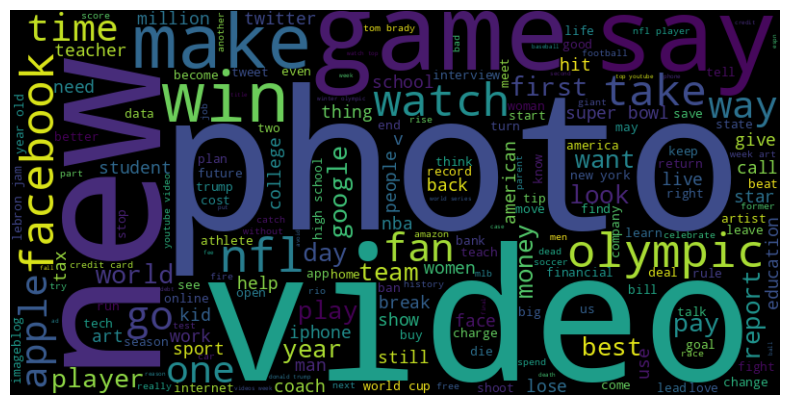

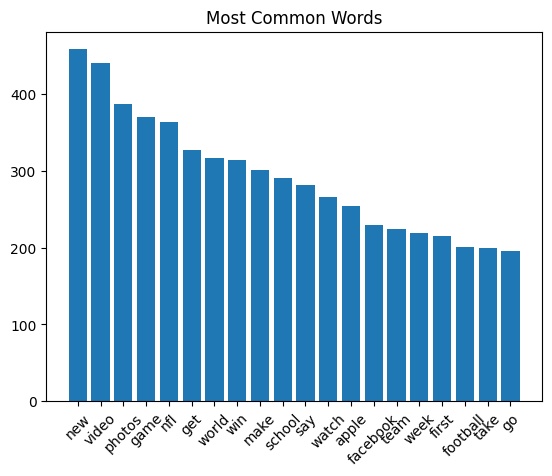

In [50]:
from wordcloud import WordCloud
from collections import Counter
all_words = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

word_freq = Counter(all_words.split())
common_words = word_freq.most_common(20)

plt.bar(*zip(*common_words))
plt.title('Most Common Words')
plt.xticks(rotation=45)
plt.show()

In [51]:
print(data.columns)

Index(['headline', 'category', 'cleaned_text'], dtype='object')


In [52]:
from tensorflow.keras.utils import to_categorical

X = data['cleaned_text'].values
y = data['category'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Initialize and fit LabelEncoder
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Now use to_categorical
y_train_encoded = to_categorical(y_train_enc)
y_test_encoded = to_categorical(y_test_enc)

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

In [53]:
model1 = Sequential()
model1.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model1.add(SimpleRNN(units=64, return_sequences=False))
model1.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [54]:
from tensorflow.keras.layers import Dropout
model2 = Sequential()

model2.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_len
))

model2.add(LSTM(64))

model2.add(Dropout(0.5))

model2.add(Dense(
    y_train_encoded.shape[1],
    activation='softmax'
))

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [55]:
from gensim.models import Word2Vec
embedding_dim = 300

# Prepare tokenized text corpus
tokenized_text = [text.split() for text in data['cleaned_text']]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=embedding_dim, window=5, min_count=1)

# Create the embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]


model3 = Sequential()
model3.add(Embedding(input_dim=vocab_size,
                     output_dim=embedding_dim,
                     input_length=max_len,
                     weights=[embedding_matrix],
                     trainable=True))  # freeze embeddings
model3.add(LSTM(units=64, return_sequences=False))
model3.add(Dropout(0.5))
model3.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))

model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [56]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

import time

start_time = time.time()

history1 = model1.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

end_time = time.time()

rnn_time = end_time - start_time

print(f"Simple RNN Training Time: {rnn_time:.2f} seconds")

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5647 - loss: 1.1350 - val_accuracy: 0.8169 - val_loss: 0.5583
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9310 - loss: 0.2344 - val_accuracy: 0.7971 - val_loss: 0.6334
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9848 - loss: 0.0654 - val_accuracy: 0.8101 - val_loss: 0.7023
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9936 - loss: 0.0265 - val_accuracy: 0.8124 - val_loss: 0.7277
Simple RNN Training Time: 8.07 seconds


In [57]:
# Add class weights to combat imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights))
start_time = time.time()

history2 = model2.fit(
    X_train_pad,
    y_train_encoded,
    class_weight=class_weight_dict,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

end_time = time.time()

lstm_time = end_time - start_time

print(f"LSTM Training Time: {lstm_time:.2f} seconds")

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3640 - loss: 1.4180 - val_accuracy: 0.8197 - val_loss: 0.5425
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8969 - loss: 0.3901 - val_accuracy: 0.8373 - val_loss: 0.5110
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9624 - loss: 0.1702 - val_accuracy: 0.8390 - val_loss: 0.4948
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9810 - loss: 0.0864 - val_accuracy: 0.8379 - val_loss: 0.6297
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9871 - loss: 0.0586 - val_accuracy: 0.8248 - val_loss: 0.7671
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9942 - loss: 0.0286 - val_accuracy: 0.8294 - val_loss: 0.7457
LSTM Training Time: 10.57 seconds


In [58]:
start_time = time.time()

history3 = model3.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

end_time = time.time()

w2v_time = end_time - start_time

print(f"LSTM + Word2Vec Training Time: {w2v_time:.2f} seconds")

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5016 - loss: 1.2691 - val_accuracy: 0.7738 - val_loss: 0.6126
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8551 - loss: 0.4315 - val_accuracy: 0.8588 - val_loss: 0.4768
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9662 - loss: 0.1298 - val_accuracy: 0.8571 - val_loss: 0.5240
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9831 - loss: 0.0609 - val_accuracy: 0.8537 - val_loss: 0.5892
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9941 - loss: 0.0287 - val_accuracy: 0.8481 - val_loss: 0.6287
LSTM + Word2Vec Training Time: 9.83 seconds


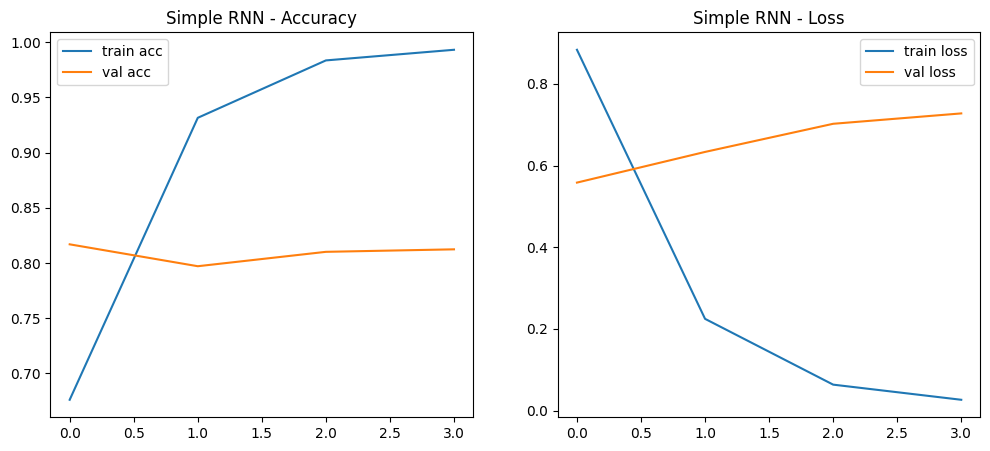

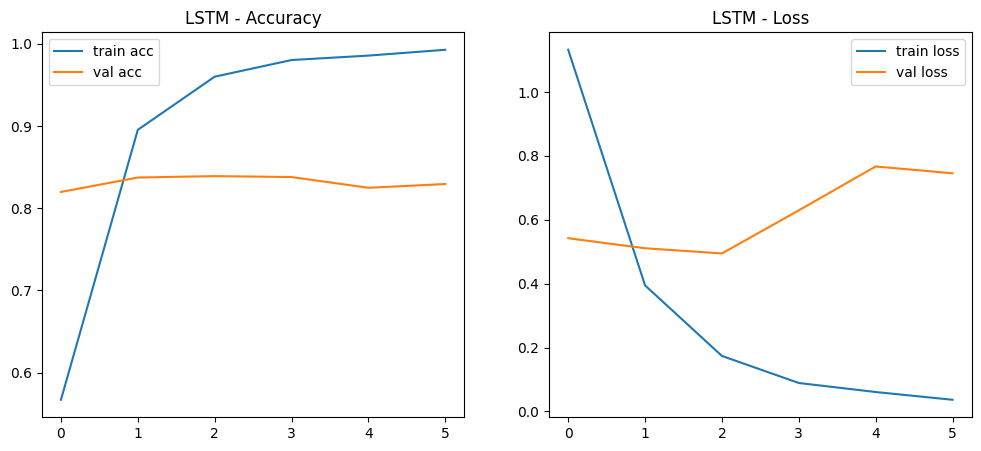

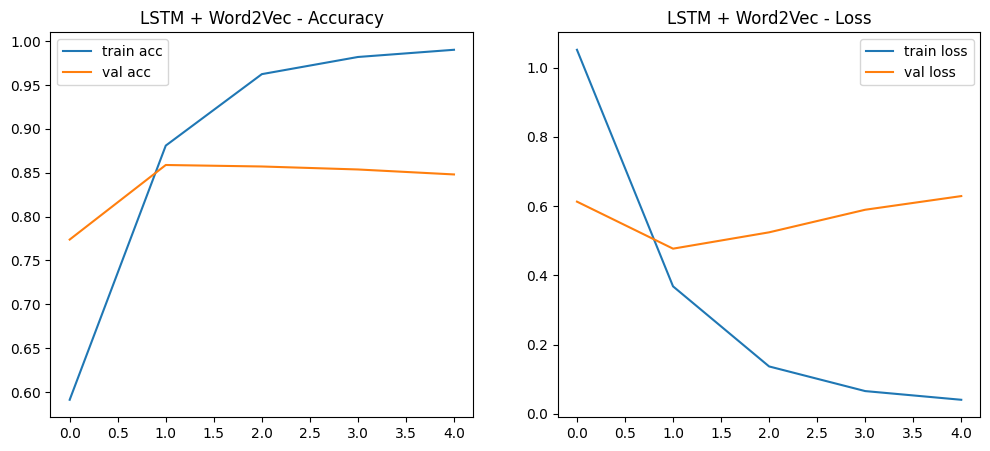

In [59]:
def plot_history(history, title):
    plt.figure(figsize=(12, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    
    plt.show()

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "LSTM + Word2Vec")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.58      0.69       224
           1       0.65      0.58      0.61       193
           2       0.73      0.79      0.76       338
           3       0.87      0.95      0.91      1020
           4       0.79      0.74      0.76       430

    accuracy                           0.81      2205
   macro avg       0.78      0.73      0.75      2205
weighted avg       0.81      0.81      0.81      2205

Confusion Matrix:


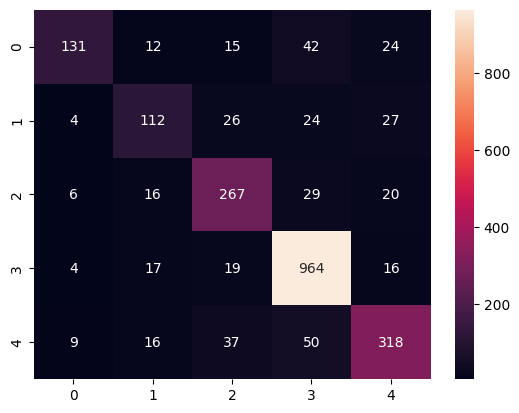

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.79      0.70       224
           1       0.73      0.67      0.70       193
           2       0.78      0.76      0.77       338
           3       0.93      0.93      0.93      1020
           4       0.83      0.76      0.80       430

    accuracy                           0.84      2205
   macro avg       0.78      0.78      0.78      2205
weighted avg       0.84      0.84      0.84      2205

Confusion Matrix:


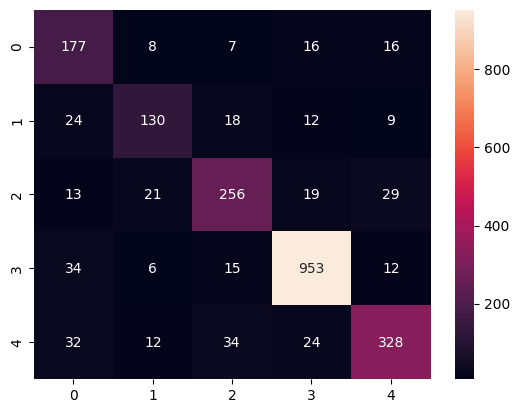

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.69      0.75       224
           1       0.88      0.62      0.72       193
           2       0.74      0.85      0.79       338
           3       0.90      0.96      0.93      1020
           4       0.83      0.78      0.81       430

    accuracy                           0.85      2205
   macro avg       0.83      0.78      0.80      2205
weighted avg       0.85      0.85      0.85      2205

Confusion Matrix:


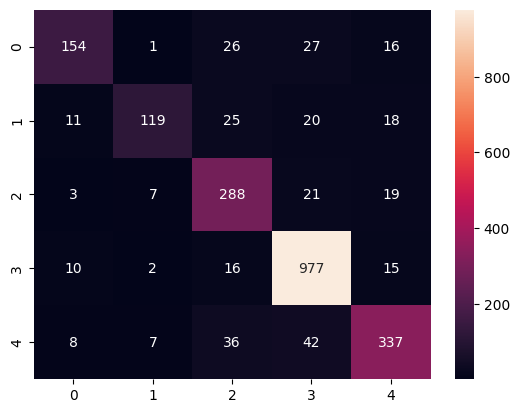

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
def evaluate_model(model, X_test_pad, y_test_encoded):
    y_pred = model.predict(X_test_pad)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test_encoded, axis=1)

    print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
    print("Confusion Matrix:")
    sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes), annot=True, fmt='d')
    plt.show()

evaluate_model(model1, X_test_pad, y_test_encoded)
evaluate_model(model2, X_test_pad, y_test_encoded)
evaluate_model(model3, X_test_pad, y_test_encoded)

In [61]:
import pickle
# Save Model 1: Simple RNN
model1.save("model_rnn.keras")

# Save Model 2: LSTM
model2.save("model_lstm.keras")

# Save Model 3: LSTM + Word2Vec
model3.save("model_lstm_word2vec.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [62]:
# ─── 4.5.4 Error Analysis ────────────────────────────────────────────────────

# Use Model 2 (LSTM) for error analysis — best balance of speed & accuracy
y_pred_probs = model2.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)

# Find misclassified indices
misclassified_idx = np.where(y_pred_classes != y_true_classes)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true_classes)}")

# Show 3 misclassified examples
print("\n=== 3 Misclassified Examples ===\n")
for i in misclassified_idx[:3]:
    true_label  = label_encoder.inverse_transform([y_true_classes[i]])[0]
    pred_label  = label_encoder.inverse_transform([y_pred_classes[i]])[0]
    original_text = X_test[i]
    print(f"Text     : {original_text[:120]}")
    print(f"True     : {true_label}")
    print(f"Predicted: {pred_label}")
    print("-" * 70)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Total misclassified: 361 / 2205

=== 3 Misclassified Examples ===

Text     : ronald page go gamble spree atm spit unlimited cash
True     : MONEY
Predicted: CULTURE & ARTS
----------------------------------------------------------------------
Text     : get raise happen
True     : MONEY
Predicted: TECH
----------------------------------------------------------------------
Text     : social media con artists
True     : TECH
Predicted: CULTURE & ARTS
----------------------------------------------------------------------


In [63]:
import gradio as gr

def predict_news_category(text, model_choice):
    processed = preprocess_text(text)
    
    if model_choice == "Simple RNN":
        prediction = model1.predict(processed)
    elif model_choice == "LSTM":
        prediction = model2.predict(processed)
    else:
        prediction = model3.predict(processed)
    
    pred_index = np.argmax(prediction, axis=1)[0]
    category = label_encoder.inverse_transform([pred_index])[0]
    
    return f"Predicted Category: {category}"

iface = gr.Interface(
    fn=predict_news_category,
    inputs=[
        gr.Textbox(label="Enter Text", placeholder="Type a news headline..."),
        gr.Radio(choices=["Simple RNN", "LSTM", "LSTM with Word2Vec"], label="Model")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="News Category Classifier"
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://8c8624d76bc9aa1589.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
